In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Train.csv to Train.csv


In [3]:
df = pd.read_csv("Train.csv")

In [4]:
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [5]:
print(df.isnull().sum())

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [6]:
X = df.drop("Reached.on.Time_Y.N", axis=1)
y = df["Reached.on.Time_Y.N"]

In [11]:
X_encoded = X.copy()

cat_cols = X_encoded.select_dtypes(include='object').columns

for col in cat_cols:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [13]:
X_train,X_test,y_train,y_test = train_test_split(

    X_scaled,
    y,
    test_size=0.25,
    random_state=42
)

In [14]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [15]:
y_pred = xgb_model.predict(X_test)

In [16]:
print("Accuracy:",
      accuracy_score(y_test,y_pred))

print("Precision:",
      precision_score(y_test,y_pred))

print("Recall:",
      recall_score(y_test,y_pred))

Accuracy: 0.6690909090909091
Precision: 0.8178694158075601
Recall: 0.576969696969697


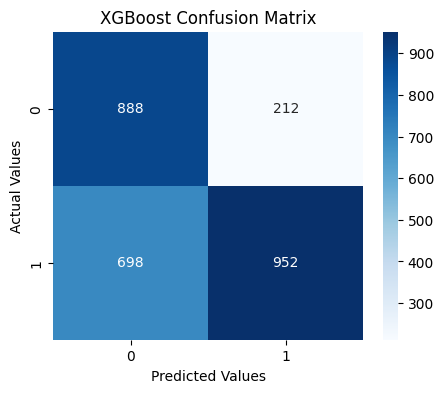

In [17]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("XGBoost Confusion Matrix")
plt.show()